In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")

# Load the raw data (use ../ to go up one folder level first)
df = pd.read_csv('../data/raw/bank-additional-full.csv', sep=';')

# 1. Check basic shape and data types
print("--- Dataset Info ---")
df.info()

# 2. Check the class imbalance of the target variable ('y')
print("\n--- Target Variable Distribution (%) ---")
print(df['y'].value_counts(normalize=True) * 100)

# 3. Preview the first few rows
df.head()

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


Dropped 'duration' column.

--- Percentage of 'unknown' values per column ---
job: 0.80%
marital: 0.19%
education: 4.20%
default: 20.87%
housing: 2.40%
loan: 2.40%


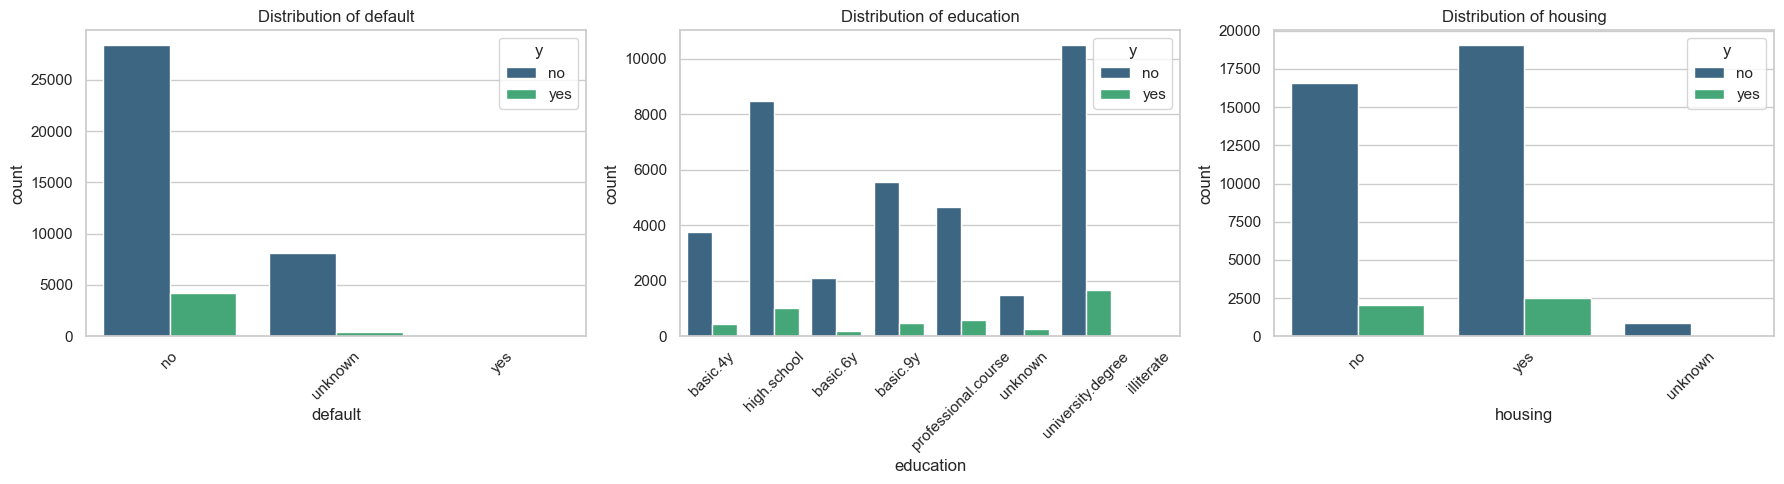

In [4]:
# 1. Drop the 'duration' column to prevent data leakage
if 'duration' in df.columns:
    df = df.drop(columns=['duration'])
    print("Dropped 'duration' column.")

# 2. Check for 'unknown' values in categorical columns
print("\n--- Percentage of 'unknown' values per column ---")
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    unknown_pct = (df[col] == 'unknown').mean() * 100
    if unknown_pct > 0:
        print(f"{col}: {unknown_pct:.2f}%")
        
# 3. Quick visualization of the categorical distributions
# Let's look at the top 3 features with the most unknowns
cols_to_plot = ['default', 'education', 'housing']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(cols_to_plot):
    sns.countplot(data=df, x=col, hue='y', ax=axes[i], palette='viridis')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# 1. Convert the target variable to binary (0 and 1)
df_clean = df.copy()
df_clean['y'] = df_clean['y'].map({'no': 0, 'yes': 1})

# 2. One-Hot Encode all categorical features
# This automatically treats 'unknown' as a distinct feature (e.g., 'default_unknown')
X = pd.get_dummies(df_clean.drop(columns=['y']), drop_first=True)
y = df_clean['y']

# 3. Stratified Train-Test Split (keeps the 11% imbalance intact in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Apply SMOTE only to the training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("--- Data Splitting & Oversampling Complete ---")
print(f"Original Training shape: {X_train.shape}")
print(f"Original Training Target Dist:\n{y_train.value_counts(normalize=True) * 100}\n")

print(f"SMOTE Training shape: {X_train_resampled.shape}")
print(f"SMOTE Training Target Dist:\n{y_train_resampled.value_counts(normalize=True) * 100}")

--- Data Splitting & Oversampling Complete ---
Original Training shape: (32950, 52)
Original Training Target Dist:
y
0    88.734446
1    11.265554
Name: proportion, dtype: float64

SMOTE Training shape: (58476, 52)
SMOTE Training Target Dist:
y
0    50.0
1    50.0
Name: proportion, dtype: float64


Training XGBoost model...

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      7310
           1       0.52      0.42      0.47       928

    accuracy                           0.89      8238
   macro avg       0.73      0.69      0.70      8238
weighted avg       0.88      0.89      0.89      8238

ROC-AUC Score: 0.7866


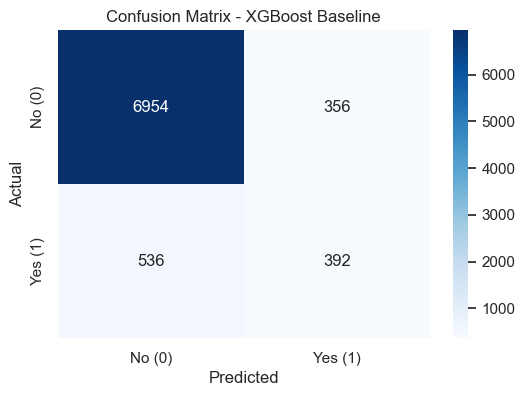

In [6]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize the XGBoost Classifier
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')

# 2. Train the model on the BALANCED training data
print("Training XGBoost model...")
xgb_model.fit(X_train_resampled, y_train_resampled)

# 3. Make predictions on the UNBALANCED (real-world) test data
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# 4. Evaluate the model
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# 5. Visualize the Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No (0)', 'Yes (1)'], 
            yticklabels=['No (0)', 'Yes (1)'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - XGBoost Baseline')
plt.show()

--- Classification Report (Threshold: 0.3) ---
              precision    recall  f1-score   support

           0       0.94      0.90      0.92      7310
           1       0.41      0.57      0.48       928

    accuracy                           0.86      8238
   macro avg       0.68      0.73      0.70      8238
weighted avg       0.88      0.86      0.87      8238



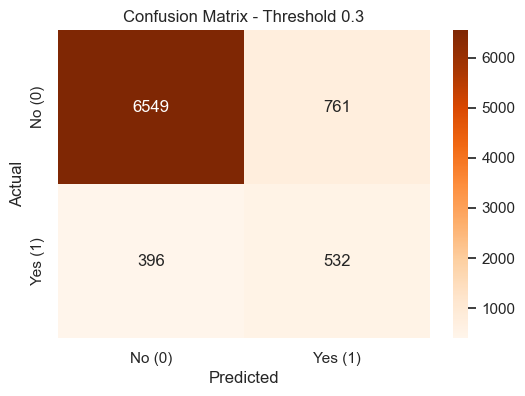

In [7]:
import numpy as np

# Let's test a lower threshold
custom_threshold = 0.30

# Use the probabilities we already calculated
y_pred_adjusted = (y_prob >= custom_threshold).astype(int)

# Evaluate the adjusted predictions
print(f"--- Classification Report (Threshold: {custom_threshold}) ---")
print(classification_report(y_test, y_pred_adjusted))

# Visualize the NEW Confusion Matrix
plt.figure(figsize=(6, 4))
cm_adjusted = confusion_matrix(y_test, y_pred_adjusted)
sns.heatmap(cm_adjusted, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['No (0)', 'Yes (1)'], 
            yticklabels=['No (0)', 'Yes (1)'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title(f'Confusion Matrix - Threshold {custom_threshold}')
plt.show()

Calculating SHAP values... (this might take a few seconds)


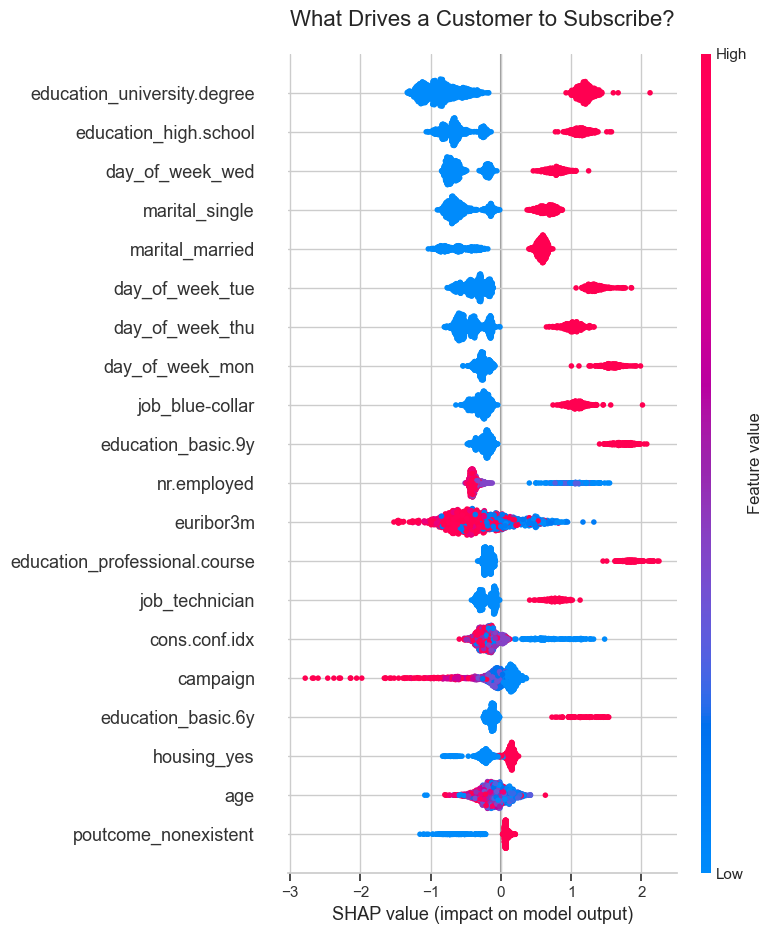

In [8]:
import shap

# Initialize JavaScript visualizations for SHAP (often needed in Jupyter)
shap.initjs()

print("Calculating SHAP values... (this might take a few seconds)")

# 1. Initialize the SHAP explainer with your trained XGBoost model
explainer = shap.TreeExplainer(xgb_model)

# 2. Calculate SHAP values for the test set
# We use a sample of 1500 rows to keep the computation fast, 
# but it's enough to see the global trends.
X_test_sample = X_test.sample(n=1500, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

# 3. Generate the SHAP Summary Plot
plt.figure(figsize=(10, 6))
plt.title('What Drives a Customer to Subscribe?', fontsize=16, pad=20)
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.tight_layout()
plt.show()